In [1]:
using Oceananigans
using Oceananigans.Units
using CairoMakie

In [2]:

# load the full 3d dye fields without placing every saved time in memory
dye_on = FieldTimeSeries(
    "amazon_rivers_on_dye_3d_test.jld2",
    "dye";
    backend = OnDisk()
)

dye_off = FieldTimeSeries(
    "amazon_rivers_off_dye_3d_test.jld2",
    "dye";
    backend = OnDisk()
)

# recover each grid from its corresponding output file
grid_on = dye_on.grid
grid_off = dye_off.grid

# determine how many snapshots are available in both simulations
Nt = min(length(dye_on.times), length(dye_off.times))

# select the shared portions of the saved time coordinates
times_on = dye_on.times[1:Nt]
times_off = dye_off.times[1:Nt]

# convert the model times from seconds to days for plotting
times_days = dye_on.times[1:Nt]./ days

0.0:1.0:60.0

In [3]:
# lower boundary of the surface region.
requested_cutoff = -100.0

# obtain the vertical cell faces and centers.
_, _, z_faces = nodes(grid_on, Center(), Center(), Face())
_, _, z_centers = nodes(grid_on, Center(), Center(), Center())

z_faces = collect(z_faces)
z_centers = collect(z_centers)

# find the model face nearest -100 m.
nearest_face_index = argmin(abs.(z_faces .- requested_cutoff))
actual_cutoff = z_faces[nearest_face_index]

# check thzt rounding moved the boundary by <20m
cutoff_error = abs(actual_cutoff - requested_cutoff)
@assert cutoff_error <= 20.0 "Nearest model face is more than 20 m from -100 m."

# create binary weight fields (changed from fractional):
#   1 = cell center is above the selected model face
#   0 = cell center is below the selected model face
upper_100m_fraction = CenterField(grid_on)
upper_100m_frac_off = CenterField(grid_off)

set!(upper_100m_fraction, (λ, φ, z) -> z > actual_cutoff ? 1.0 : 0.0)
set!(upper_100m_frac_off, (λ, φ, z) -> z > actual_cutoff ? 1.0 : 0.0)

# report the layers that contrbiute
contributing_layers = findall(z_centers .> actual_cutoff)

4-element Vector{Int64}:
 17
 18
 19
 20

In [4]:
# define a helper function that evaluates an oceananigans integral
function scalar_volume_integral(field)

    # multiply concentration of the cell & volume
    integral_operation = Integral(field, dims = (1, 2, 3))

    # wrap the operation in a field that can store its result
    integral_field = Field(integral_operation)

    compute!(integral_field)

    # a complete three-dimensional reduction contains one scalar value
    # array transfers that value to a regular cpu array if necessary
    return Array(interior(integral_field))[1]
end

upper_100m_amount_on = zeros(Float64, Nt)
upper_100m_amount_off = zeros(Float64, Nt)

for n in 1:Nt
    # read one freshwater-on and freshwater-off snapshot
    dye_snapshot_on = dye_on[n]
    dye_snapshot_off = dye_off[n]

    # multiply by the upper-100-m fractional array
    weighted_dye_on = dye_snapshot_on * upper_100m_fraction
    weighted_dye_off = dye_snapshot_off * upper_100m_frac_off

    # integrate concentration times the native cell volume
    # conceptually, this calculates sum([]*volume*weight)
    upper_100m_amount_on[n] = scalar_volume_integral(weighted_dye_on)
    upper_100m_amount_off[n] = scalar_volume_integral(weighted_dye_off)
end

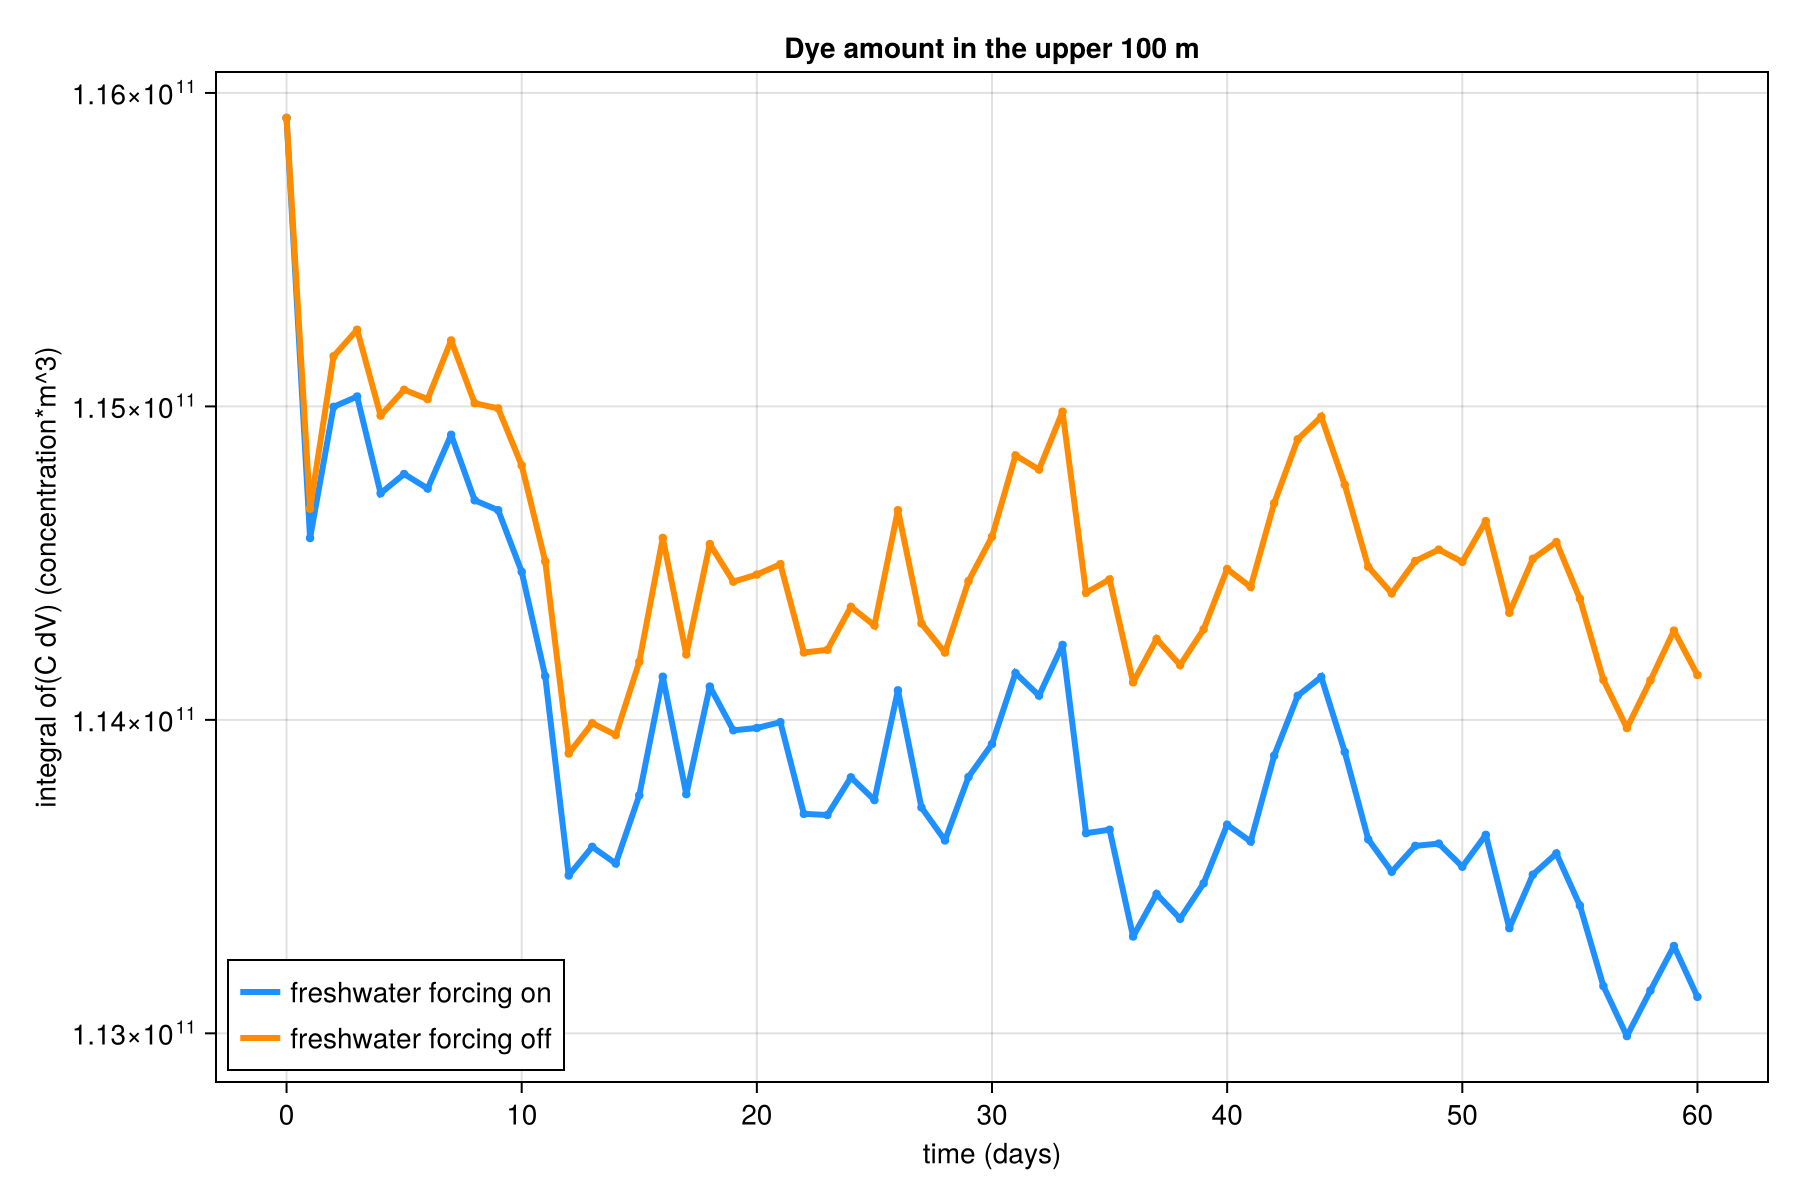

In [5]:
# compare init dye amounts + scale the difference 
initial_difference = upper_100m_amount_on[1] - upper_100m_amount_off[1]

# scale the difference so the comparison does not depend on tracer magnitude
initial_scale = max(
    abs(upper_100m_amount_on[1]),
    abs(upper_100m_amount_off[1]),
    eps(Float64)
)

relative_initial_difference = abs(initial_difference) / initial_scale

# calculate the final fraction of the initial upper-ocean amount
fraction_remaining_on = upper_100m_amount_on[end] / upper_100m_amount_on[1]
fraction_remaining_off = upper_100m_amount_off[end] / upper_100m_amount_off[1]

# create the requested comparison figure
figure = Figure(size = (900, 600))

axis = Axis(
    figure[1, 1],
    title = "Dye amount in the upper 100 m",
    xlabel = "time (days)",
    ylabel = "integral of(C dV) (concentration*m^3)"
)

# plot the freshwater-on result
lines!(
    axis,
    times_days,
    upper_100m_amount_on;
    color = :dodgerblue,
    linewidth = 3,
    label = "freshwater forcing on"
)

# mark the individual freshwater-on outputs
scatter!(
    axis,
    times_days,
    upper_100m_amount_on;
    color = :dodgerblue,
    markersize = 6
)

# plot the freshwater-off control result
lines!(
    axis,
    times_days,
    upper_100m_amount_off;
    color = :darkorange,
    linewidth = 3,
    label = "freshwater forcing off"
)

# mark the individual freshwater-off outputs
scatter!(
    axis,
    times_days,
    upper_100m_amount_off;
    color = :darkorange,
    markersize = 6
)

# identify the two simulations
axislegend(axis; position = :lb)

# make sure the destination directory exists
mkpath("figures")

# use the final saved day in the output filename
final_day = round(Int, times_days[end])

# save the completed figure
save(
    "figures/amazon_upper_100m_dye_inventory_day$(final_day).png",
    figure
)

# display the result in the notebook
figure

In [16]:
println("init diff = ", relative_initial_difference)
println("shared snapshots = ", Nt)
println("uppr-ocean cutoff = ", actual_cutoff, " m")
println("layers = ", contributing_layers)

init diff = 0.0
shared snapshots = 61
uppr-ocean cutoff = -91.46143497375284 m
layers = [17, 18, 19, 20]


In [7]:
using Oceananigans.ImmersedBoundaries: mask_immersed_field!

function dye_min_max(filename)
    dye = FieldTimeSeries(filename, "dye"; backend=OnDisk())

    smallest = Inf
    largest = -Inf

    for n in eachindex(dye.times)
        dye_field = dye[n]

        # exclude immersed land cells
        mask_immersed_field!(dye_field, NaN)

        values = Array(interior(dye_field))
        wet_values = values[isfinite.(values)]

        smallest = min(smallest, minimum(wet_values))
        largest = max(largest, maximum(wet_values))
    end

    return smallest, largest
end

on_min, on_max = dye_min_max("amazon_rivers_on_dye_3d_test.jld2")
off_min, off_max = dye_min_max("amazon_rivers_off_dye_3d_test.jld2")

println("freshwater forcing on:")
println("minimum dye concentration = ", on_min)
println("maximum dye concentration = ", on_max)

println("\nfreshwater forcing off:")
println("minimum dye concentration = ", off_min)
println("maximum dye concentration = ", off_max)

freshwater forcing on:
minimum dye concentration = -0.29586338996887207
maximum dye concentration = 1.0109513998031616

freshwater forcing off:
minimum dye concentration = -0.2891831398010254
maximum dye concentration = 1.0113216638565063


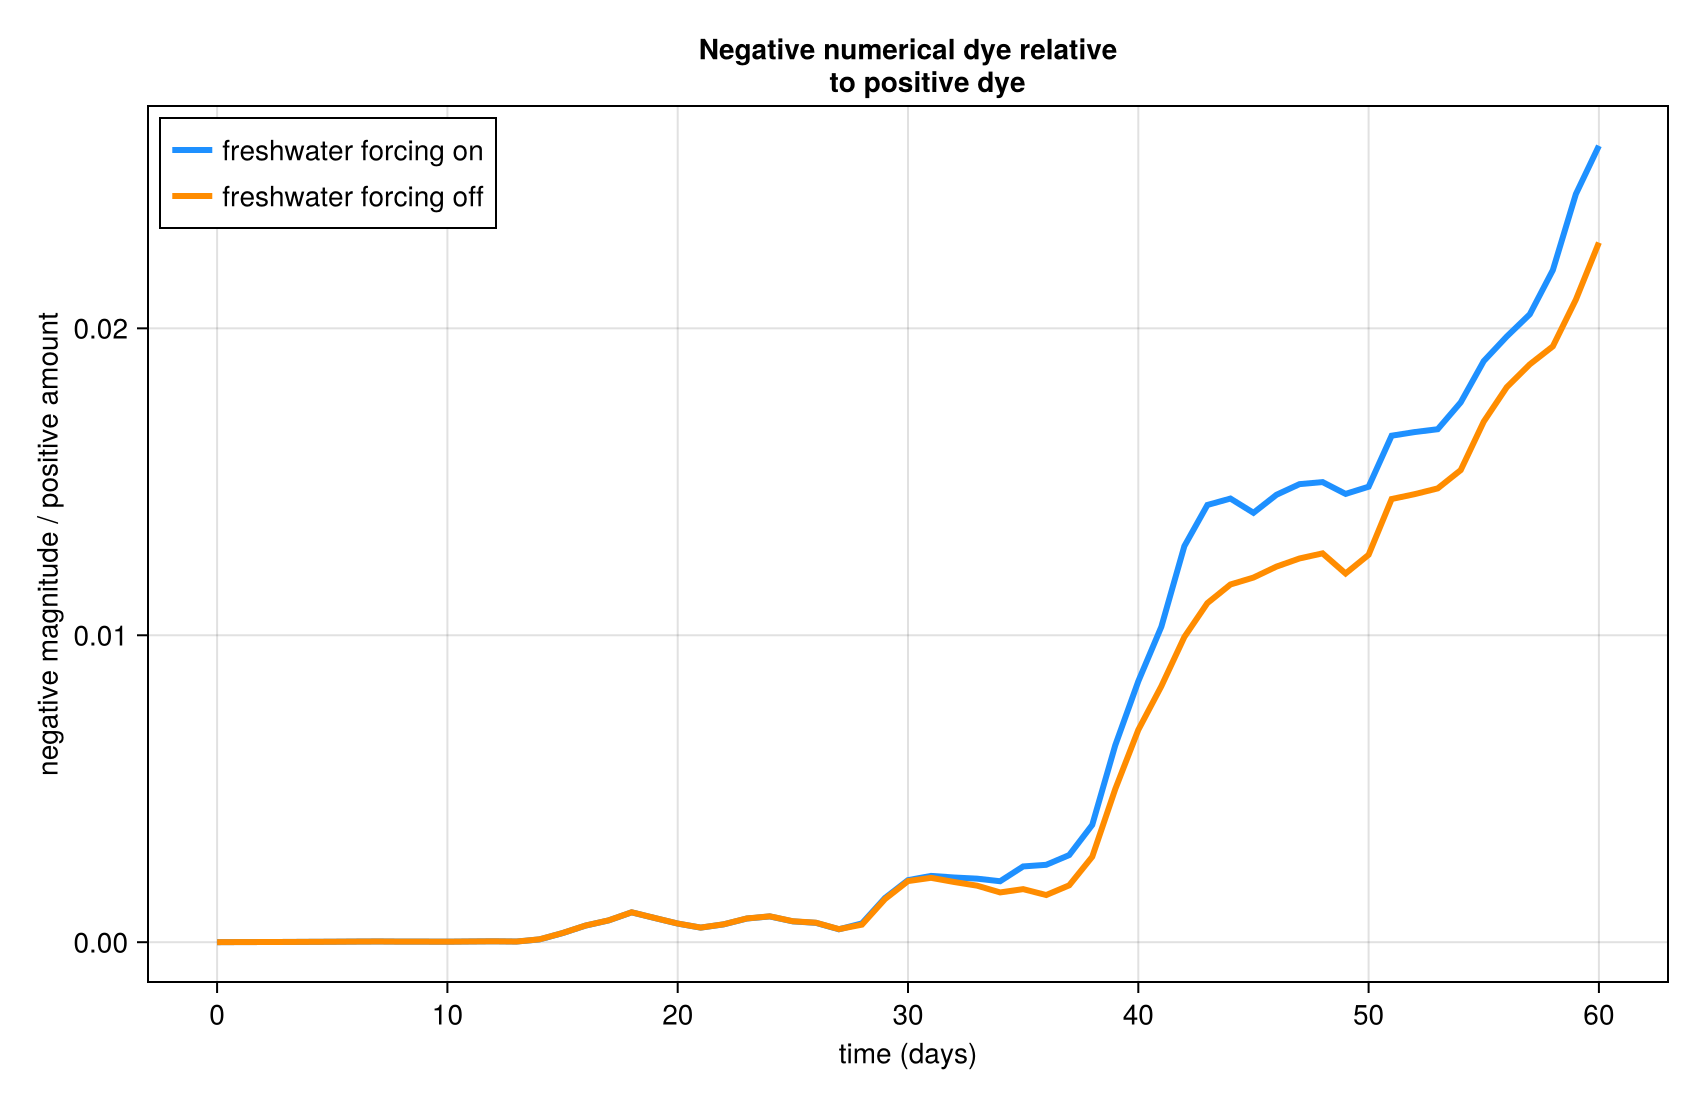

In [ ]:
# check how much negative dye is being created

positive_amount_on = zeros(Nt)
positive_amount_off = zeros(Nt)

negative_amount_on = zeros(Nt)
negative_amount_off = zeros(Nt)

positive_field_on = CenterField(grid_on)
positive_field_off = CenterField(grid_off)

negative_field_on = CenterField(grid_on)
negative_field_off = CenterField(grid_off)

for n in 1:Nt
    d_on = Array(interior(dye_on[n])) #concentration arrays 
    d_off = Array(interior(dye_off[n]))

    # separate the positive and negative parts
    interior(positive_field_on) .= max.(d_on, 0)
    interior(positive_field_off) .= max.(d_off, 0)

    interior(negative_field_on) .= max.(-d_on, 0) # get magnitude of engative dye concentrations
    interior(negative_field_off) .= max.(-d_off, 0)

    # multiply by volume & fraction --> total dye amt 
    positive_amount_on[n] = scalar_volume_integral(positive_field_on * upper_100m_fraction)
    positive_amount_off[n] = scalar_volume_integral(positive_field_off * upper_100m_frac_off)

    negative_amount_on[n] = scalar_volume_integral(negative_field_on * upper_100m_fraction)
    negative_amount_off[n] = scalar_volume_integral(negative_field_off * upper_100m_frac_off)
end

# amt of negative dye relative to positive dye at any given time 
negative_fraction_on = negative_amount_on ./ positive_amount_on
negative_fraction_off = negative_amount_off ./ positive_amount_off

fig = Figure(size = (850, 550))

ax = Axis(
    fig[1, 1],
    title = "Negative numerical dye relative
     to positive dye",
    xlabel = "time (days)",
    ylabel = "negative magnitude / positive amount"
)

lines!(
    ax,
    times_days,
    negative_fraction_on;
    color = :dodgerblue,
    linewidth = 3,
    label = "freshwater forcing on"
)

lines!(
    ax,
    times_days,
    negative_fraction_off;
    color = :darkorange,
    linewidth = 3,
    label = "freshwater forcing off"
)

axislegend(ax; position = :lt)

mkpath("figures")
save("figures/amazon_dye_numerical_undershoot.png", fig)

fig

freshwater forcing on:
minimum dye concentration = -0.1691083163022995
maximum dye concentration = 0.991666853427887

freshwater forcing off:
minimum dye concentration = -0.046742040663957596
maximum dye concentration = 0.9896662831306458


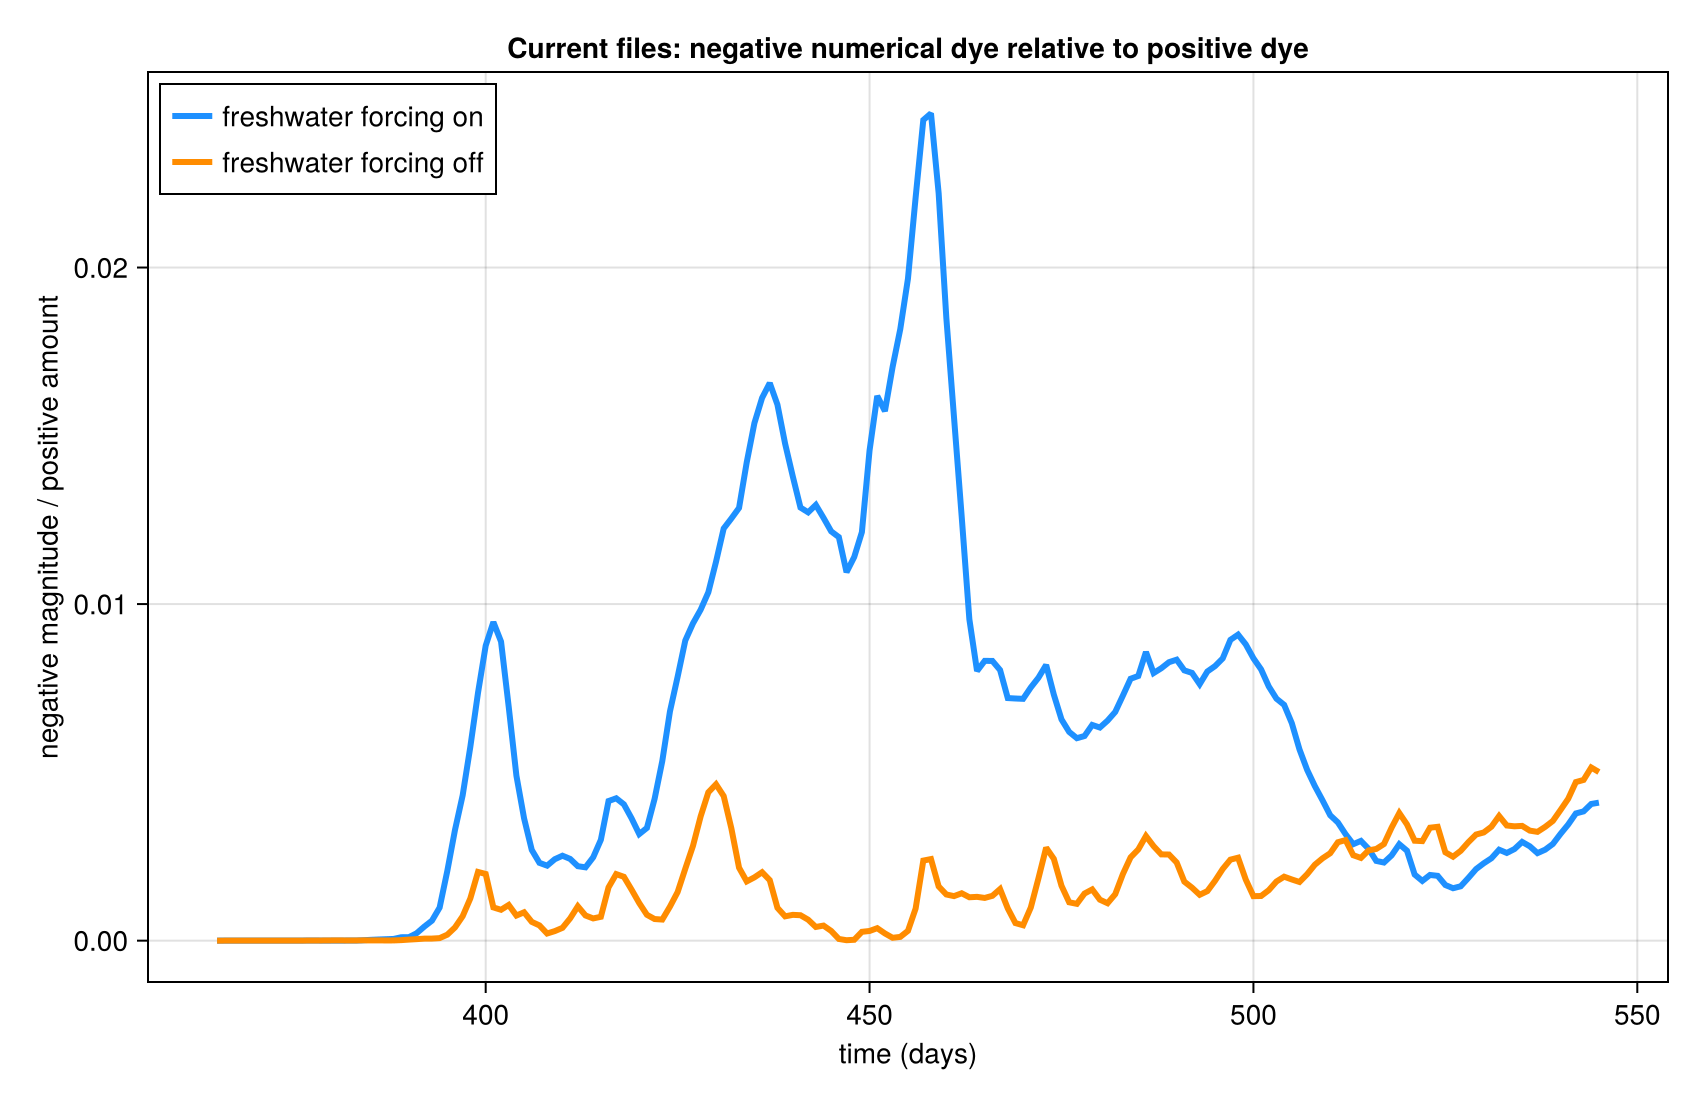

In [17]:
using Oceananigans.ImmersedBoundaries: mask_immersed_field!

on_min, on_max = dye_min_max("amazon_rivers_on_dye_3d.jld2")
off_min, off_max = dye_min_max("amazon_rivers_off_dye_3d.jld2")

println("freshwater forcing on:")
println("minimum dye concentration = ", on_min)
println("maximum dye concentration = ", on_max)

println("\nfreshwater forcing off:")
println("minimum dye concentration = ", off_min)
println("maximum dye concentration = ", off_max)

# check how much negative dye is being created
# load the current dye files
dye_on_current = FieldTimeSeries(
    "amazon_rivers_on_dye_3d.jld2",
    "dye";
    backend = OnDisk()
)

dye_off_current = FieldTimeSeries(
    "amazon_rivers_off_dye_3d.jld2",
    "dye";
    backend = OnDisk()
)

grid_on_current = dye_on_current.grid
grid_off_current = dye_off_current.grid

# use the saved times available in both current simulations
Nt_current = min(
    length(dye_on_current.times),
    length(dye_off_current.times)
)

times_days_current = dye_on_current.times[1:Nt_current] ./ days

# find the current model face nearest to -100 m
_, _, z_faces_current = nodes(
    grid_on_current,
    Center(),
    Center(),
    Face()
)

z_faces_current = collect(z_faces_current)

requested_cutoff_current = -100.0
nearest_face_current = argmin(
    abs.(z_faces_current .- requested_cutoff_current)
)

actual_cutoff_current = z_faces_current[nearest_face_current]

# create upper-100-m masks for the current grids
upper_100m_on_current = CenterField(grid_on_current)
upper_100m_off_current = CenterField(grid_off_current)

set!(
    upper_100m_on_current,
    (λ, φ, z) -> z > actual_cutoff_current ? 1.0 : 0.0
)

set!(
    upper_100m_off_current,
    (λ, φ, z) -> z > actual_cutoff_current ? 1.0 : 0.0
)

# create arrays for the integrated positive and negative amounts
positive_amount_on_current = zeros(Nt_current)
positive_amount_off_current = zeros(Nt_current)

negative_amount_on_current = zeros(Nt_current)
negative_amount_off_current = zeros(Nt_current)

# create fields for storing the separated concentrations
positive_field_on_current = CenterField(grid_on_current)
positive_field_off_current = CenterField(grid_off_current)

negative_field_on_current = CenterField(grid_on_current)
negative_field_off_current = CenterField(grid_off_current)

for n in 1:Nt_current
    d_on = Array(interior(dye_on_current[n]))
    d_off = Array(interior(dye_off_current[n]))

    # retain only positive concentrations
    interior(positive_field_on_current) .= max.(d_on, 0)
    interior(positive_field_off_current) .= max.(d_off, 0)

    # store negative concentrations as positive magnitudes
    interior(negative_field_on_current) .= max.(-d_on, 0)
    interior(negative_field_off_current) .= max.(-d_off, 0)

    # integrate the positive amounts in the upper 100 m
    positive_amount_on_current[n] = scalar_volume_integral(
        positive_field_on_current * upper_100m_on_current
    )

    positive_amount_off_current[n] = scalar_volume_integral(
        positive_field_off_current * upper_100m_off_current
    )

    # integrate the negative magnitudes in the upper 100 m
    negative_amount_on_current[n] = scalar_volume_integral(
        negative_field_on_current * upper_100m_on_current
    )

    negative_amount_off_current[n] = scalar_volume_integral(
        negative_field_off_current * upper_100m_off_current
    )
end

# calculate negative dye relative to positive dye
negative_fraction_on_current = (
    negative_amount_on_current ./ positive_amount_on_current
)

negative_fraction_off_current = (
    negative_amount_off_current ./ positive_amount_off_current
)

# plot the current-file results
fig_current = Figure(size = (850, 550))

ax_current = Axis(
    fig_current[1, 1],
    title = "Current files: negative numerical dye relative to positive dye",
    xlabel = "time (days)",
    ylabel = "negative magnitude / positive amount"
)

lines!(
    ax_current,
    times_days_current,
    negative_fraction_on_current;
    color = :dodgerblue,
    linewidth = 3,
    label = "freshwater forcing on"
)

lines!(
    ax_current,
    times_days_current,
    negative_fraction_off_current;
    color = :darkorange,
    linewidth = 3,
    label = "freshwater forcing off"
)

axislegend(ax_current; position = :lt)

mkpath("figures")

save(
    "figures/amazon_dye_numerical_undershoot_current.png",
    fig_current
)

fig_current